# Цель анализа

Цель исследования – оценить влияние различных факторов на эффективность работы сотрудников компании.

Для достижения цели необходимо провести анализ статистических данных о сотрудниках компании, включая возраст, образование, стаж, показатели KPI, участие в обучении и награды. Результаты исследования могут быть использованы для построения аналитических моделей, например, модели прогнозирования повышения, которая позволит отделу HR принимать более обоснованные решения о развитии и продвижении персонала.

In [1]:
# Импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Используем очищенный датасет HR Analysis Case Study. Выполняем предобработку.

In [2]:
# Загрузка и предобработка данных
df = pd.read_csv("data.csv")

df.rename(columns={
    'no_of_trainings': 'trainings_count',
    'length_of_service': 'service_years',
    'KPIs_met >80%': 'kpi_met_80',
    'awards_won?': 'awards_won'
}, inplace=True)

df['gender'] = df['gender'].replace({'m': 'male', 'f': 'female'})
df['education'] = df['education'].str.lower().replace({
    "bachelor's": 'bachelor',
    "master's & above": 'master',
    "secondary": 'secondary'
})

df['previous_year_rating'] = df['previous_year_rating'].fillna(0).astype(int)
df['education'] = df['education'].fillna('secondary')
df.drop(columns='employee_id', inplace=True)

print("Размерность после предобработки:", df.shape)


Размерность после предобработки: (23490, 12)


## Гипотезы

H1 – Сотрудники с более высоким уровнем образования (бакалавр, магистр) демонстрируют большую вероятность достижения показателей KPI ≥80%, чем сотрудники со средним образованием.

H2 – С увеличением продолжительности работы в компании растет вероятность выполнения KPI - опытные сотрудники чаще достигают целей.

H3 – Высокие оценки за предыдущий период коррелируют с повышенной вероятностью выполнения KPI.

# Исследовательский анализ данных

In [3]:
# Настройки отображения графиков Matplotlib
plt.rcParams.update({
    "figure.figsize": (7, 4),         # Размер графиков по умолчанию
    "axes.titlesize": 14,             # Размер шрифта заголовков
    "axes.labelsize": 12,             # Размер шрифта подписей осей
    "xtick.labelsize": 10,            # Размер шрифта делений оси X
    "ytick.labelsize": 10,            # Размер шрифта делений оси Y
    "axes.grid": True,                # Включение сетки на графиках
    "grid.alpha": 0.3,                # Прозрачность линий сетки
    "grid.linestyle": "--",           # Стиль линий сетки
})

# Настройка стиля и палитры seaborn
sns.set_palette("muted")
sns.set_style("whitegrid")

Построим гистограммы числовых признаков и опишем форму распределений.

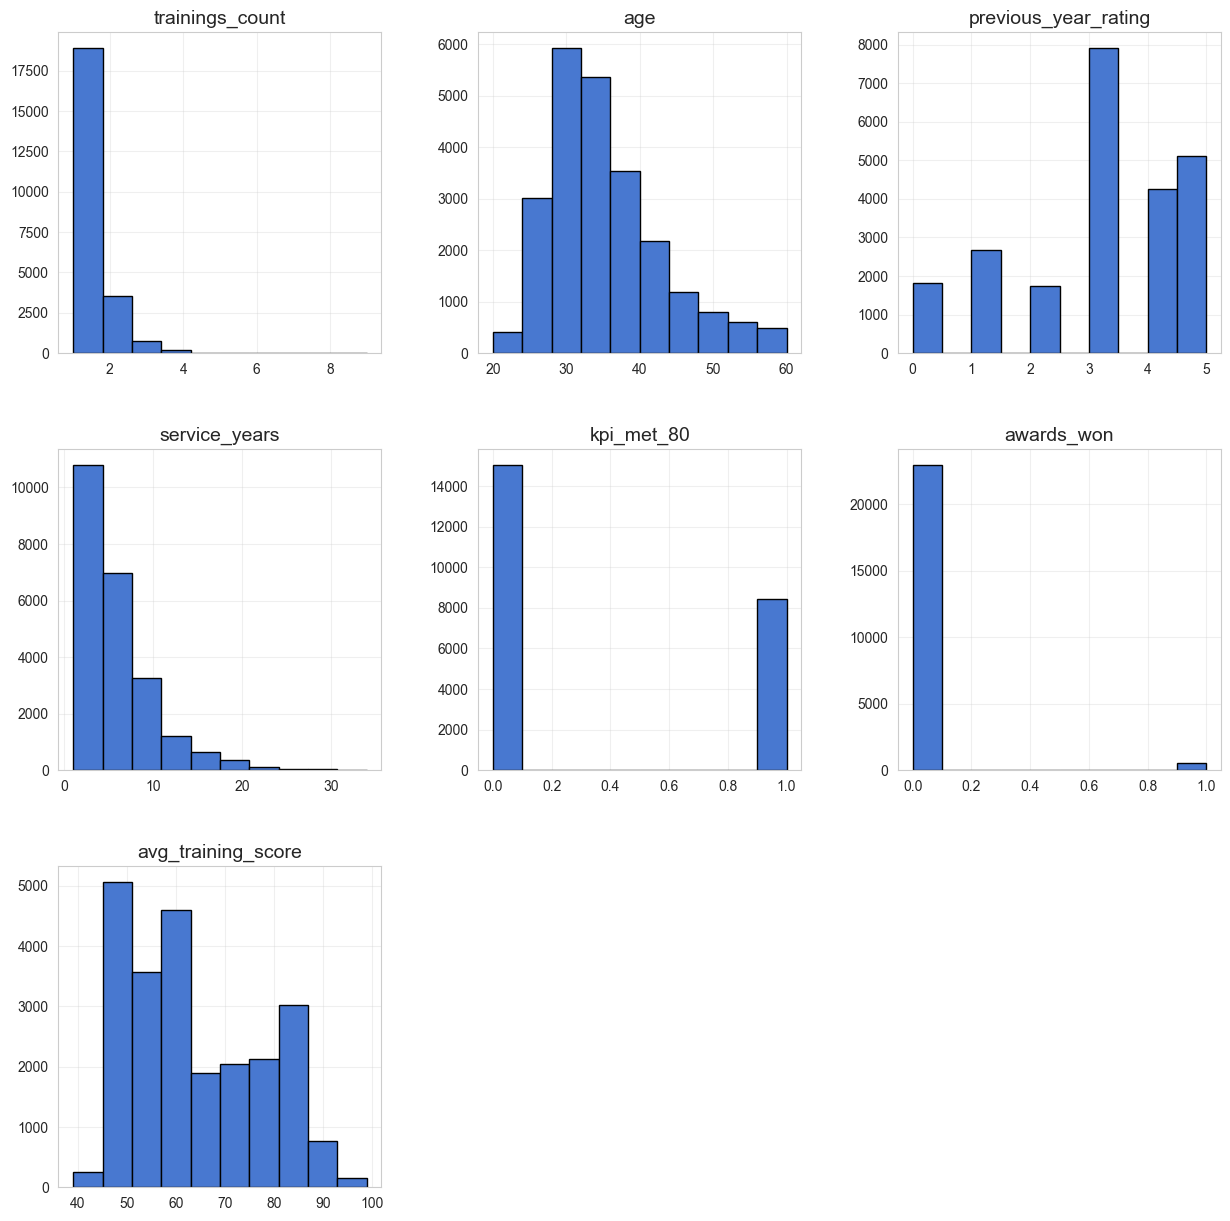

In [4]:
# Гистограммы для всех числовых признаков
df.hist(edgecolor='black',
        linewidth=1,
        figsize=(15, 15))
plt.show()

*	Распределение количества посещенных тренингов (trainings_count) резко скошено влево: подавляющее большинство сотрудников проходили 1-2 тренинга, которые вероятно являются обязательными для сотрудников.
*	Распределение возраста (age) близко к нормальному, но имеет небольшое смещение вправо - пик в 30-35 лет. Коллектив преимущественно средневозрастной - крайние значения (20 и 60) редки, но реалистичны.
*	Дискретное распределение по шкале от 0 до 5.
Наибольшая частота наблюдается у значений 3-5, что указывает на преобладание сотрудников с положительными оценками. (previous_year_rating)
*	Распределение стажа (service_years) скошено влево: большинство сотрудников работают до 10 лет, пик на уровне 3-5 лет. Небольшое количество выбросов у сотрудников со стажем более 20 лет.
*	Около 60% сотрудников не достигли порога 80% KPI, а 40% выполнили KPI (kpi_met_80).
*	Подавляющее большинство сотрудников не получали награды, только около 1-2% имеют награды (awards_won).
*	У большинства сотрудников результаты обучения выше 50, средний балл около 60 (avg_training_score). Вероятно проходной балл для прохождения тренинга - 50 баллов.

Проверим гипотезу о нормальности распределений с помощью теста Shapiro-Wilk. При p-value ≤ 0.05 распределение статистически отличается от нормального.

In [ ]:
# Проверка нормальности распределений (тест Шapiro-Wilk, выборка до 5000 наблюдений)
from scipy import stats

numeric_cols = ['trainings_count', 'age', 'previous_year_rating',
                'service_years', 'avg_training_score']

normality_rows = []
for col in numeric_cols:
    sample = df[col].dropna()
    if len(sample) > 5000:
        sample = sample.sample(5000, random_state=42)
    stat, p_value = stats.shapiro(sample)
    normality_rows.append({
        'признак': col,
        'W-статистика': round(stat, 4),
        'p-value': round(p_value, 6),
        'нормальное': 'да' if p_value > 0.05 else 'нет'
    })

pd.DataFrame(normality_rows)


,признак,W-статистика,p-value,нормальное
0,trainings_count,0.4697,0.0,нет
1,age,0.9269,0.0,нет
2,previous_year_rating,0.8946,0.0,нет
3,service_years,0.8556,0.0,нет
4,avg_training_score,0.9261,0.0,нет


Boxplot поможет увидеть выбросы и сравнить разброс признаков.

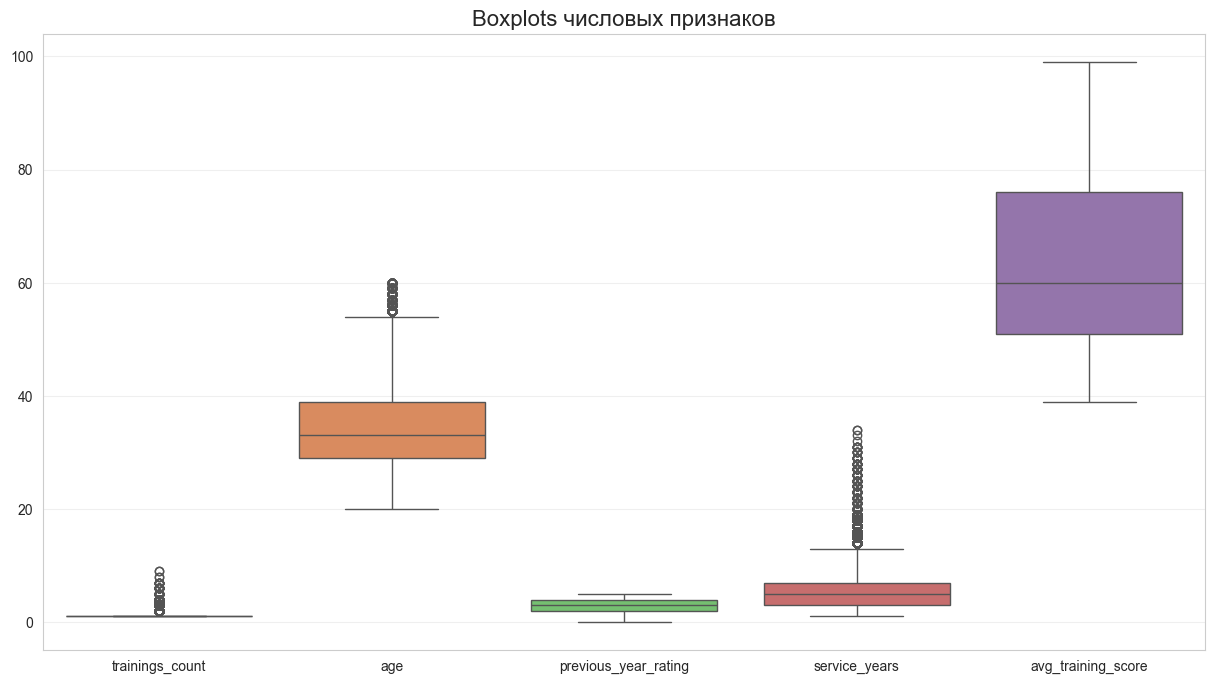

In [6]:
# Boxplot для визуализации распределений числовых признаков и выбросов
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[['trainings_count', 'age', 'previous_year_rating',
                     'service_years', 'avg_training_score']])
plt.title('Boxplots числовых признаков', fontsize=16)
plt.show()

Выбросы присутствуют, но незначительно влияют на общую структуру - большинство из них реалистичны для HR-данных.
* trainings_count (количество тренингов): Основная масса значений сосредоточена вблизи 1. Наблюдаются отдельные выбросы (3+ тренингов), что соответствует активным сотрудникам, участвующим во множестве программ развития.
* age (возраст): медиана около 33 лет, несколько выбросов выше 55 лет - вероятно, сотрудники старшего возраста, близкие к пенсионному, но эти выбросы не являются ошибками.
* previous_year_rating (оценка по предыдущему году): оценки сотрудников ограничены шкалой, поэтому распределение компактное и без экстремальных значений.
* service_years (стаж работы): медиана около 5 лет, межквартильный диапазон от 2 до 8 лет, выбросы выше 20-25 лет - редкие, но реалистичные случаи долгосрочной работы.
* avg_training_score (средний балл за обучение) - медиана около 60 баллов, межквартильный диапазон - от 50 до 75, что отражает средний уровень прохождения тренингов.

Выбросы присутствуют, но являются реалистичными (долгий стаж, активные участники обучения, высокие результаты). Исключать их нет необходимости.

Построим корреляционную матрицу и визуализируем её в виде heatmap.

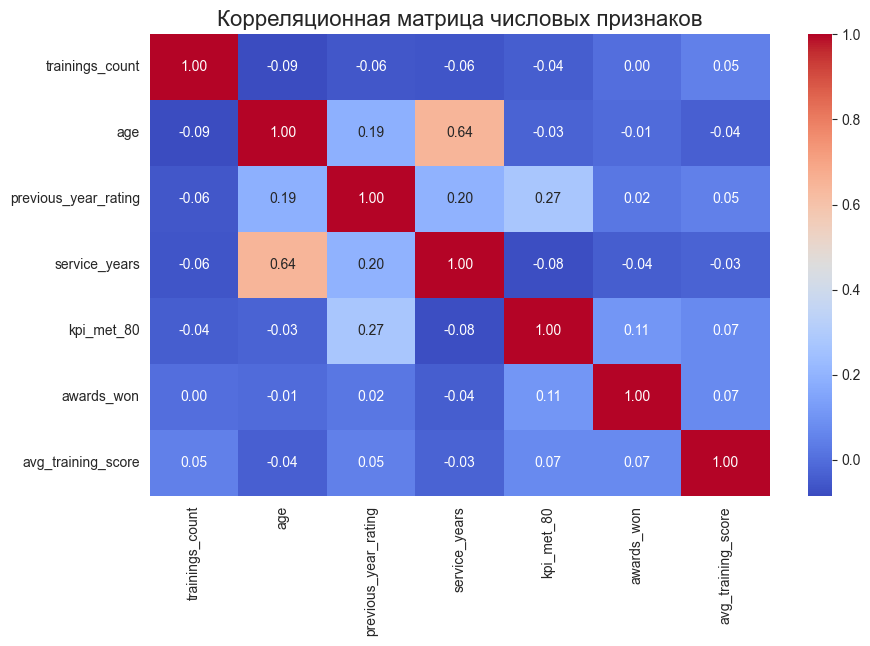

In [7]:
# Тепловая карта корреляций между признаками
plt.figure(figsize=(10, 6))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица числовых признаков', fontsize=16)
plt.show()

Очевидная зависимость age и service_years (0,64): с увеличением возраста растёт и стаж работы. Это логично, так как старшие сотрудники, как правило, дольше работают в компании.

Сотрудники, которые получили высокую оценку за прошлый год, чаще выполняют KPI (previous_year_rating и kpi_met_80 -> 0.27).

Более опытные сотрудники в среднем получают более высокие оценки (previous_year_rating и service_years -> 0.20), что может отражать влияние опыта на эффективность.

avg_training_score и trainings_count почти не связаны с другими показателями (все < 0.1). Это означает, что количество и успехи при прохождении тренингов не влияют на KPI или оценку работы.

awards_won слабо коррелирует со всеми признаками. Это говорит о том, что награды не зависят напрямую от количественных метрик - возможно, они присуждаются за качественные достижения или инициативность.

Диаграммы рассеяния покажут связь между ключевыми числовыми признаками.

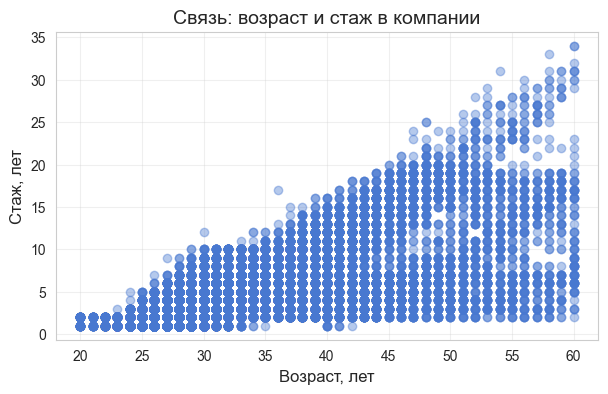

In [8]:
# Диаграмма рассеяния: возраст и стаж
plt.figure()
plt.scatter(df['age'], df['service_years'], alpha=0.4)
plt.title("Связь: возраст и стаж в компании")
plt.xlabel("Возраст, лет")
plt.ylabel("Стаж, лет")
plt.show()

Зависимость линейная и положительная: с ростом возраста увеличивается стаж работы. Для сотрудников до 25 лет стаж обычно не превышает 2-3 лет, что логично для новичков или недавних выпускников. В возрасте 30-45 лет распределение становится шире: есть как новые сотрудники, так и те, кто работает уже более 10 лет. Для возрастной группы старше 50 лет встречаются сотрудники с очень большим стажем - до 30-35 лет.

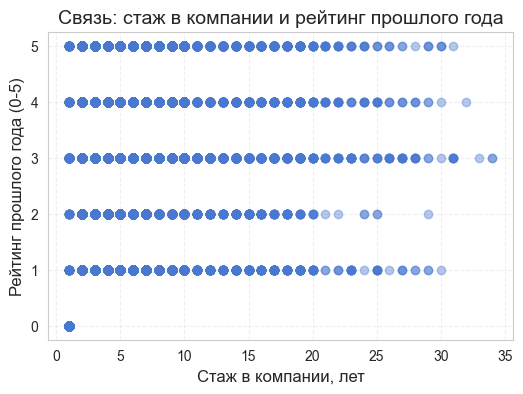

In [9]:
# Диаграмма рассеяния: стаж и рейтинг прошлого года
plt.figure(figsize=(6,4))
plt.scatter(df['service_years'], df['previous_year_rating'], alpha=0.4)
plt.title("Связь: стаж в компании и рейтинг прошлого года")
plt.xlabel("Стаж в компании, лет")
plt.ylabel("Рейтинг прошлого года (0-5)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

Сотрудники с любым стажем могут иметь как низкие, так и высокие рейтинги.
Однако видна умеренная тенденция: у работников со стажем 5-15 лет оценки чаще находятся в диапазоне 3-5, то есть среди них больше стабильных, опытных сотрудников с высокими результатами.

Проверим гипотезы о влиянии пола и образования на выполнение KPI.

C:\Users\Pelmeshka\AppData\Local\Temp\ipykernel_18076\2242227183.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


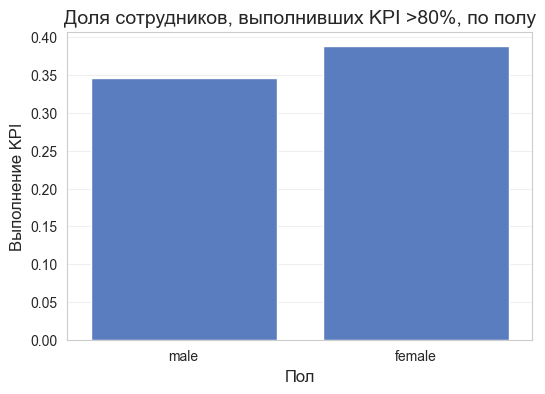

In [10]:
# Выполнение KPI >80% по полу
plt.figure(figsize=(6,4))
sns.barplot(
    x='gender',
    y='kpi_met_80',
    data=df,
    ci=None
)
plt.title('Доля сотрудников, выполнивших KPI >80%, по полу')
plt.xlabel('Пол')
plt.ylabel('Выполнение KPI')
plt.show()

Женщины демонстрируют слегка более высокую долю выполнения KPI (0.38), чем мужчины (0.35). Но в целом гендерных различий в достижении KPI практически нет.

C:\Users\Pelmeshka\AppData\Local\Temp\ipykernel_18076\3752169906.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


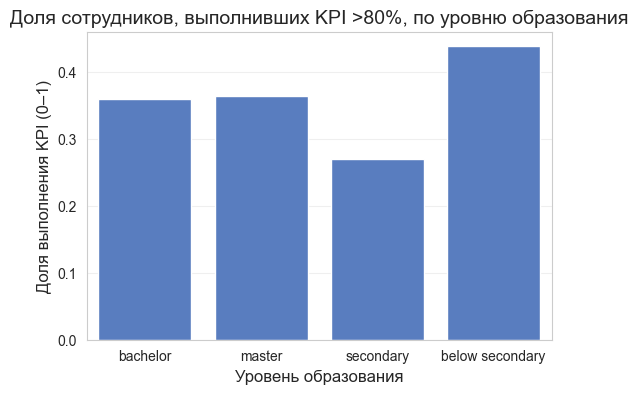

In [11]:
# Выполнение KPI >80% по уровню образования
plt.figure(figsize=(6,4))
sns.barplot(
    x='education',
    y='kpi_met_80',
    data=df,
    ci=None
)
plt.title('Доля сотрудников, выполнивших KPI >80%, по уровню образования')
plt.xlabel('Уровень образования')
plt.ylabel('Доля выполнения KPI (0–1)')
plt.show()

Уровень образования оказывает положительное влияние на достижение KPI. Сотрудники с высшим образованием немного чаще демонстрируют стабильные результаты и достижение ключевых показателей.

# Заключение

В ходе исследовательского анализа изучены распределения признаков, выявлены выбросы и построена корреляционная матрица.

Подтверждение гипотез:
- H1 (образование => KPI): частично подтверждена – сотрудники с более высоким образованием чаще выполняют KPI.
- H2 (стаж => KPI): подтверждена умеренно – опытные сотрудники чаще достигают KPI.
- H3 (рейтинг => KPI): подтверждена – корреляция previous_year_rating и kpi_met_80 положительная (≈0.27).

Ключевые закономерности: сильная связь возраста и стажа (≈0.64); слабая связь метрик обучения с KPI; награды почти не коррелируют с остальными показателями.